In [137]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [138]:
filename = "/content/drive/MyDrive/EE6347/v_newbatch.txt" #include the files given in zip file and gice appropriate path for all the files

This file is for post processing the data generated by simulation of hardware implementation of the FFNN. Histogram data for each letter. 

USE {letter}_newbatch.txt FOR ALL HISTOGRAM PLOTS

THEN WE USE SCATTERING TO DETERMINE THE ACCURACY AS WELL. We were able to acheive an accuracy of about 25%. Further work to improve the accuracy underway.

In [139]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# BLOCK 1 — Parse the multi-node file
# ============================================================
def parse_multinode_file(filename):
    """
    Parses a single file containing blocks like:
    time A
    <t> <v>

    time T
    <t> <v>
    ...
    """
    nodes = {}
    current_node = None
    times, volts = [], []

    with open(filename, 'r') as f:
        for line in f:
            line = line.strip()

            # Blank line marks end of a block
            if line == "":
                if current_node is not None:
                    nodes[current_node] = (np.array(times), np.array(volts))
                current_node = None
                times, volts = [], []
                continue

            # Detect header: "time A"
            if line.startswith("time"):
                parts = line.split()
                if len(parts) == 2:
                    current_node = parts[1]   # A, T, V, X
                continue

            # Data line: "<time> <voltage>"
            if current_node is not None:
                t_str, v_str = line.split()
                times.append(float(t_str))
                volts.append(float(v_str))

    # Store last block if file ends without blank line
    if current_node is not None and len(times) > 0:
        nodes[current_node] = (np.array(times), np.array(volts))

    return nodes

In [140]:
def get_closest_value(times, volts, target_time, tol=0.001):
    idx = np.argmin(np.abs(times - target_time))
    if abs(times[idx] - target_time) <= tol:
        return volts[idx]
    return None


In [141]:
def count_from_multinode_file(filename, time_points, tol=0.001):
    nodes = parse_multinode_file(filename)

    counts = {"A": 0, "T": 0, "V": 0, "X": 0}

    for tp in time_points:
        node_values = {}

        for node_name, (t_arr, v_arr) in nodes.items():
            val = get_closest_value(t_arr, v_arr, tp, tol)
            if val is not None:
                node_values[node_name] = val

        if not node_values:
            continue

        winner = max(node_values, key=node_values.get)
        counts[winner] += 1

    return counts



In [142]:
def window(start, end):
    l = []
    for i in range(int(start*1000), int(end*1000+1), 40):
        l.append(i/1000)   # convert back to seconds
    return l

# Build composite time schedule (in seconds)
time_points = \
    window(0.180, 0.540) + \
    window(0.740, 1.100) + \
    window(1.300, 1.660) + \
    window(1.860, 2.060) + \
    window(2.580, 2.780) + \
    window(2.980, 3.340) + \
    window(3.540, 3.900) + \
    window(4.380, 4.460) + \
    window(4.700, 5.020) + \
    window(5.220, 5.260) + \
    window(5.820, 6.140) + \
    window(6.340, 6.540)

print("Generated", len(time_points), "time points.")

# IMPORTANT: WAVES ARE IN MICROSECONDS IN FILE
# You must convert file time from seconds (1e-6) or adjust tol appropriately.
# Here tol = 1e-6 is more reasonable:
tol = 0.01

counts = count_from_multinode_file(filename, time_points, tol=tol)
print("Counts:", counts)

Generated 91 time points.
Counts: {'A': 46, 'T': 25, 'V': 13, 'X': 7}


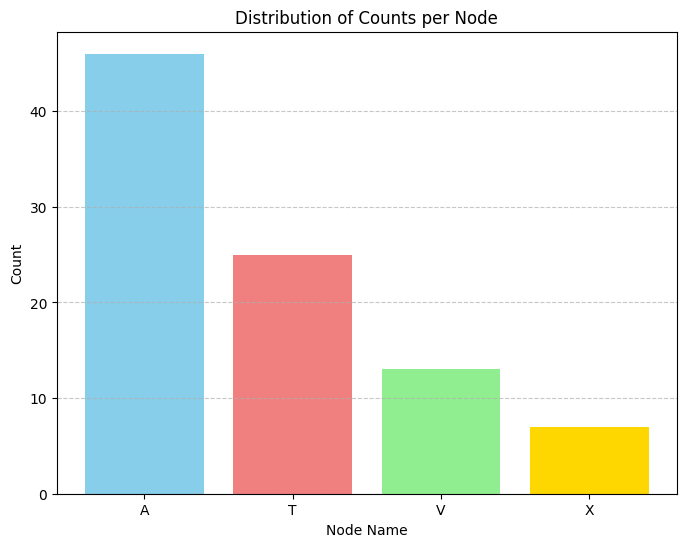

In [143]:
node_names = list(counts.keys())
node_counts = list(counts.values())

plt.figure(figsize=(8, 6))
plt.bar(node_names, node_counts, color=['skyblue', 'lightcoral', 'lightgreen', 'gold'])
plt.xlabel('Node Name')
plt.ylabel('Count')
plt.title('Distribution of Counts per Node')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [144]:
total_counts = sum(counts.values())
percentage_counts = {node: (count / total_counts) * 100 for node, count in counts.items()}

print("Percentage Distribution of Node Counts:")
for node, percentage in percentage_counts.items():
    print(f"{node}: {percentage:.2f}%")

Percentage Distribution of Node Counts:
A: 50.55%
T: 27.47%
V: 14.29%
X: 7.69%


In [145]:
import numpy as np
import csv

def load_ads_block_format(filename):
    """
    Parses multi-block ADS output:
    Each block looks like:
    time <signal>
    <time> <value>
    <time> <value>
    ...
    """
    signals = {}
    current_signal = None

    with open(filename, 'r') as f:
        for line in f:
            parts = line.strip().split()

            # Skip empty lines
            if len(parts) == 0:
                continue

            # Header start
            if parts[0] == "time":
                current_signal = parts[1]
                signals[current_signal] = {"time": [], "values": []}
                continue

            # Data row
            if current_signal:
                t, v = float(parts[0]), float(parts[1])
                signals[current_signal]["time"].append(t)
                signals[current_signal]["values"].append(v)

    return signals


def merge_signals(signals):
    """
    Convert into a unified time-aligned table.
    Assumes all time vectors are identical per block.
    """

    all_keys = list(signals.keys())
    reference = all_keys[0]

    timebase = np.array(signals[reference]["time"])
    merged = {"time": timebase}

    for sig in all_keys:
        merged[sig] = np.interp(timebase,
                                signals[sig]["time"],
                                signals[sig]["values"])
    return merged


def dump_selected_multicol(output_filename, query_times, merged_dict):
    """
    Writes only selected time steps into CSV.
    Columns: time, sig1, sig2, ...
    """

    keys = list(merged_dict.keys())
    timebase = merged_dict["time"]

    with open(output_filename, "w", newline="") as f:
        writer = csv.writer(f)

        # Write header
        writer.writerow(keys)

        # For each requested timestamp
        for tq in query_times:
            row = []
            for k in keys:
                if k == "time":
                    v = tq
                else:
                    v = np.interp(tq, timebase, merged_dict[k])
                row.append(v)

            writer.writerow(row)


# -------------------- Usage --------------------

input_file = filename
output_file = "/content/drive/MyDrive/EE6347/V_160_1.csv"  #include the files given in zip file and gice appropriate path for all the files

# Load signals from ADS output
signals = load_ads_block_format(input_file)

# Merge into a unified aligned dict
merged = merge_signals(signals)

# Choose time instants of interest (seconds)
# query_times = [5e-3, 25e-3, 45e-3, 65e-3, 165e-3]

query_times = time_points


# Store only selected timestamps
dump_selected_multicol(output_file, query_times, merged)

print(f"Done! Exported selected time steps → {output_file}")

Done! Exported selected time steps → /content/drive/MyDrive/EE6347/V_160_1.csv


First 5 rows of the CSV data:


,time,A,T,V,X
0,0.18,0.082570,0.039031,0.036636,0.040256
1,0.22,0.113474,0.060855,0.057214,0.054898
2,0.26,0.103067,0.054671,0.055676,0.051527
3,0.30,0.086927,0.045045,0.045186,0.046364
4,0.34,0.088188,0.049731,0.054619,0.043209


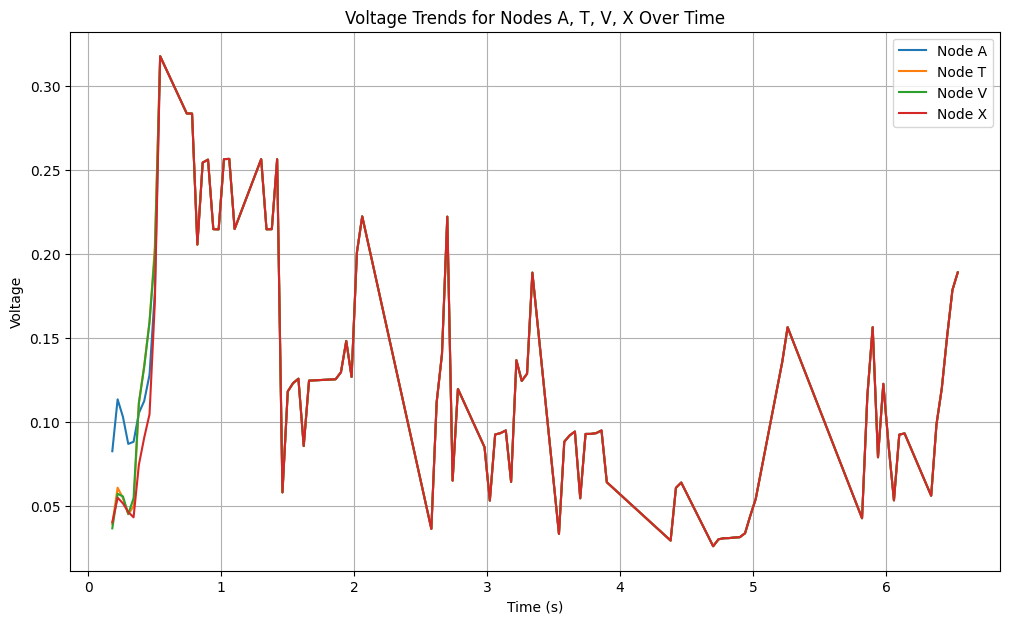

In [146]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the CSV file into a DataFrame
output_file = '/content/drive/MyDrive/EE6347/V_160_1.csv'  #include the files given in zip file and gice appropriate path for all the files
df_csv = pd.read_csv(output_file)

# Display the first few rows to confirm the data structure
print("First 5 rows of the CSV data:")
display(df_csv.head())

# Plotting the data
plt.figure(figsize=(12, 7))

# Plot each node's voltage against time
for column in df_csv.columns:
    if column != 'time':  # Assuming 'time' is the x-axis
        plt.plot(df_csv['time'], df_csv[column], label=f'Node {column}')

plt.xlabel('Time (s)')
plt.ylabel('Voltage')
plt.title('Voltage Trends for Nodes A, T, V, X Over Time')
plt.legend()
plt.grid(True)
plt.show()

In [147]:
import pandas as pd


# Load CSV
df = pd.read_csv(output_file)

# Ignore the 'time' column
data = df.iloc[:, 1:]  # take all columns except first

# Dictionary to accumulate counts
counts = {col: 0 for col in data.columns}

# Iterate row-wise
for idx, row in data.iterrows():
    max_col = row.idxmax()  # get column name where value is maximum
    counts[max_col] += 1

print(counts)

{'A': 63, 'T': 18, 'V': 6, 'X': 4}


In [148]:
V_dict = {'A': 49, 'T': 23, 'V': 10, 'X': 9}
A_dict = {'A': 44, 'T': 31, 'V': 9, 'X': 7}
T_dict =  {'A': 54, 'T': 17, 'V': 10, 'X': 10}
X_dict =  {'A': 42, 'T': 20, 'V': 23, 'X': 6}

In [149]:
X_dict_new = {'A': 33, 'T': 17, 'V': 30, 'X': 11}
V_dict_new = {'A': 46, 'T': 25, 'V': 13, 'X': 7}
T_dict_new = {'A': 56, 'T': 27, 'V': 0, 'X': 8}
A_dict_new = {'A': 51, 'T': 18, 'V': 12, 'X': 10}

In [150]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [151]:
def remove_units(value):
    """Remove ADS units like 1e-6sec or 4e-3V and convert to float."""
    if isinstance(value, (float, int)):
        return float(value)
    v = value.replace('E', 'e').replace('sec','').replace('V','')
    return float(v)

def clean_dataframe(df):
    df['time'] = df['time'].apply(remove_units)
    for col in ['A','X','V','T']:
        df[col] = df[col].apply(remove_units)
    return df


In [152]:
def load_and_combine(A_file, X_file, V_file, T_file):
    dfA = clean_dataframe(pd.read_csv(A_file))
    dfX = clean_dataframe(pd.read_csv(X_file))
    dfV = clean_dataframe(pd.read_csv(V_file))
    dfT = clean_dataframe(pd.read_csv(T_file))

    combined = pd.concat([dfA, dfX, dfV, dfT], ignore_index=True)
    return combined


In [153]:
def sample_at(df, t_query, tol=5e-9):
    """Return A, X, V, T voltage at time closest to t_query."""
    idx = np.argmin(np.abs(df['time'] - t_query))
    if abs(df['time'].iloc[idx] - t_query) > tol:
        return None
    row = df.iloc[idx]
    return row['A'], row['X'], row['V'], row['T']


In [154]:
def build_sampled_table(df, time_points):
    sampled = []
    for tp in time_points:
        vals = sample_at(df, tp)
        if vals is None:
            sampled.append([np.nan]*4)
        else:
            sampled.append(list(vals))
    return pd.DataFrame(sampled, columns=['A','X','V','T'])


In [155]:
def scatter_plot(sampled, samples_per_class=160):
    plt.figure(figsize=(12, 5))

    plt.scatter(sampled.index, sampled['A'],  color='red',    s=12, label='A')
    plt.scatter(sampled.index, sampled['X'],  color='blue',   s=12, label='X')
    plt.scatter(sampled.index, sampled['V'],  color='orange', s=12, label='V')
    plt.scatter(sampled.index, sampled['T'],  color='green',  s=12, label='T')

    # Vertical separators for clusters
    for k, label in zip([0,1,2,3], ['A','X','V','T']):
        xmid = k*samples_per_class + samples_per_class/2
        plt.axvline(k*samples_per_class - 0.5, color='gray', linestyle='--')
        plt.text(xmid, sampled.max().max()*0.8, label, ha='center', fontsize=16)

    plt.title("Predicted Neuron Voltages for 640 Images")
    plt.xlabel("Image Index")
    plt.ylabel("Voltage (V)")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


In [156]:
def compute_accuracy(sampled, samples_per_class=160):
    predictions = sampled.idxmax(axis=1).tolist()
    true_labels = (
        ['A']*samples_per_class +
        ['X']*samples_per_class +
        ['V']*samples_per_class +
        ['T']*samples_per_class
    )
    correct = sum(predictions[i] == true_labels[i] for i in range(640))
    return correct / 640


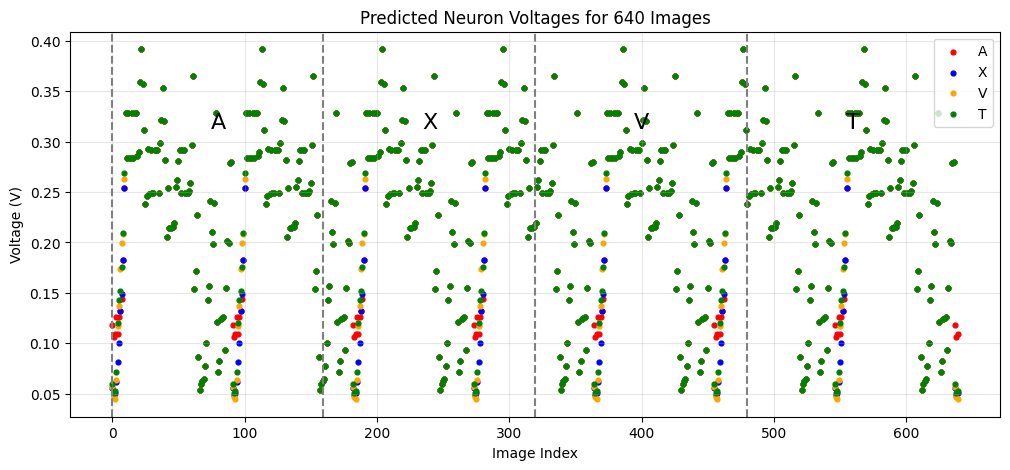



Accuracy over 640 images = 24.53125 %


In [158]:
if __name__ == "__main__":

    #include the files given in zip file and gice appropriate path for all the files
    df = load_and_combine("/content/drive/MyDrive/EE6347/A_160_1.csv", "/content/drive/MyDrive/EE6347/X_160_1.csv",
                          "/content/drive/MyDrive/EE6347/V_160_1.csv", "/content/drive/MyDrive/EE6347/T_160_1.csv")
    # Build 640 sampling times

    required_len = 640
    current_len = len(time_points)
    repeat_factor = (required_len + current_len - 1) // current_len # Ceiling division
    expanded_time_points = (time_points * repeat_factor)[:required_len]

    sampled = build_sampled_table(df, expanded_time_points)

    # Scatter plot
    scatter_plot(sampled)

    # Accuracy
    acc = compute_accuracy(sampled)
    print("\n")
    print("Accuracy over 640 images =", acc*100, "%")